# Series temporales · CSV docente recibido el 9 de octubre
Fuentes: [CSV](../../materialak/sentsorea.csv),
[plantilla de 15 tareas](../../materialak/denbora_serieak_EGIN_GABE.py) y
[PDF con 19 pasos, dos retos y repaso](../../materialak/02_Denbora_Serieak.pdf).
Esta solución conserva las fuentes. Son datos de una práctica docente;
su procedencia no demuestra mediciones de una planta real.
Desde esta carpeta: `uv sync --frozen`, después
`MPLBACKEND=Agg uv run --frozen python denbora_serieak_docente.py`.
En notebook, seleccionar el kernel del entorno de esta práctica y ejecutar
aquí. Se sobrescriben solo `resultados/docente/*`; no hay llamadas externas.
Los timestamps no llevan zona horaria. No se les atribuye UTC arbitrariamente.

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from retos_adicionales import alert_episodes

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
if not (HERE / "denbora_serieak_docente.py").is_file():
    raise ValueError("Ejecutar el notebook desde la carpeta de esta práctica")
SOURCE = HERE.parent.parent / "materialak" / "sentsorea.csv"


def load_source(path=SOURCE):
    """Leer sin alterar la fuente; rechazar ambigüedad temporal y de esquema."""
    df = pd.read_csv(path, parse_dates=["timestamp"], index_col="timestamp")
    if not isinstance(df.index, pd.DatetimeIndex) or df.index.hasnans:
        raise ValueError("timestamp debe contener fechas válidas")
    if not df.index.is_unique:
        raise ValueError(
            "Timestamps duplicados: decidir su tratamiento antes de operar"
        )
    if list(df.columns) != ["tenperatura", "bibrazioa"]:
        raise ValueError("Esquema esperado: timestamp,tenperatura,bibrazioa")
    return df.sort_index()


def analyze(df):
    interval = df.loc["2026-10-01 08:00":"2026-10-01 09:00"]
    # Resample sobre las lecturas originales: mean omite NaN, no los cuenta como 0.
    means = df.resample("10min").mean()
    enriched = df.copy()
    # Retrospectiva: solo huecos interiores, sin inventar extremos sin vecinos.
    enriched["tenperatura_beteta"] = df.tenperatura.interpolate(
        method="time", limit_area="inside"
    )
    enriched["tenperatura_leundua"] = enriched.tenperatura_beteta.rolling(5).mean()
    # Retos sobre mediciones originales, nunca convertir interpolaciones en alertas.
    above = df.loc[df.tenperatura > 50, ["tenperatura"]]
    alerts = alert_episodes(df.tenperatura)
    aggregation = df.tenperatura.resample("10min").agg(
        ["mean", "max", "min", "count", "size"]
    )
    return interval, means, enriched, above, alerts, aggregation

## Pasos 1–10: cargar, ordenar, inspeccionar, filtrar y agrupar
La plantilla separa importar, cargar, ordenar, head y shape (1–5); selección
inclusiva 08:00–09:00 y su media (6–7); medias de ambas columnas cada 10 minutos,
impresión y número de filas (8–10). El índice sustituye a timestamp como columna.
Ventanas `[08:00,08:10)` etiquetadas 08:00, etc.; una media no es un total.
Leer a continuación las tablas completas, no solo un gráfico suavizado.

In [2]:
def run(output=None):
    output = Path(output) if output is not None else HERE / "resultados" / "docente"
    output.mkdir(parents=True, exist_ok=True)
    before = hashlib.sha256(SOURCE.read_bytes()).hexdigest()
    df = load_source()
    interval, means, enriched, above, alerts, aggregation = analyze(df)
    print("1–5 · Primeras cinco lecturas:", df.head().to_string(), sep="\n")
    print("Shape (sin timestamp como columna):", df.shape)
    print("6–7 · Intervalo inclusivo:", interval.to_string(), sep="\n")
    print("Media del intervalo:", interval.tenperatura.mean())
    print("8–10 · Medias cada diez minutos:", means.to_string(), sep="\n")
    print("Filas agregadas:", len(means))
    print("11 · NaN originales:", df.isna().sum().to_dict())
    print("13 · Lecturas >50 °C:", above.to_string(), sep="\n")
    print("Retos · Episodios de tres consecutivas:", int(alerts.sum()))
    assert df.shape == (180, 2) and len(interval) == 61 and len(means) == 18
    assert df.isna().sum().to_dict() == {"tenperatura": 3, "bibrazioa": 0}
    assert enriched.tenperatura_beteta.isna().sum() == 0
    assert enriched.tenperatura_leundua.isna().sum() == 4
    assert above.index.tolist() == [pd.Timestamp("2026-10-01 09:53")]
    assert above.tenperatura.iloc[0] == 84.8 and alerts.sum() == 0
    enriched.to_csv(output / "operaciones.csv", encoding="utf-8")
    means.to_csv(output / "medias_10min.csv", encoding="utf-8")
    aggregation.to_csv(output / "agregaciones_10min.csv", encoding="utf-8")
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(df.index, df.tenperatura, label="Original docente", linewidth=1)
    ax.plot(
        enriched.index, enriched.tenperatura_leundua, label="Interpolada + rolling(5)"
    )
    ax.axhline(50, color="firebrick", linestyle="--", label="Umbral 50 °C")
    ax.set(xlabel="Hora del CSV (zona no indicada)", ylabel="Temperatura (°C)")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(output / "tenperatura.png", dpi=130)
    plt.close(fig)
    report = {
        "date": "2026-10-09",
        "source": "06_NiFi/materialak/sentsorea.csv; práctica docente",
        "source_sha256": before,
        "timezone": "unspecified in source; naive timestamps preserved",
        "rows": len(df),
        "interval_rows": len(interval),
        "interval_nonmissing_temperature": int(interval.tenperatura.count()),
        "interval_mean_temperature": float(interval.tenperatura.mean()),
        "ten_minute_windows": len(means),
        "missing_original": {k: int(v) for k, v in df.isna().sum().items()},
        "missing_interpolated": int(enriched.tenperatura_beteta.isna().sum()),
        "rolling_warmup_missing": int(enriched.tenperatura_leundua.isna().sum()),
        "above_50": [
            {"timestamp": str(t), "temperature": float(v)}
            for t, v in above.tenperatura.items()
        ],
        "alerts_three_consecutive": int(alerts.sum()),
        "raw_max": float(df.tenperatura.max()),
        "ten_minute_mean_max": float(means.tenperatura.max()),
        "rolling_max": float(enriched.tenperatura_leundua.max()),
        "scope": "Pandas exercise, not NiFi/Kafka execution or Moodle submission",
    }
    assert hashlib.sha256(SOURCE.read_bytes()).hexdigest() == before
    (output / "validacion.json").write_text(
        json.dumps(report, ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
    )
    return report

## Pasos 11–19, retos y repaso: calidad, gráfico e interpretación
11: tres NaN de temperatura, ninguno de vibración. 12: interpolación temporal
a columna nueva `tenperatura_beteta`, conservando el original. 13: filtro estricto
>50, hora y valor. 14: media de cinco medidas sobre la columna interpolada.
15: gráfico original y suavizado. 16: guardar este script; 17: ejecutarlo con
el comando uv inicial. 18: comprobar carga, tablas, relleno y gráfico (los
asserts y tests verifican las condiciones numéricas). 19: reflexiones siguientes.

Tendencia: temperatura inicial ~41 °C y final ~47 °C, creciente en estas tres
horas, con oscilaciones y un pico. No prueba degradación a largo plazo. Ruido:
fluctuaciones pequeñas se atenúan con la media móvil. Huecos: tres temperaturas
interiores se estiman entre vecinos, no son observaciones recuperadas.

Resample reduce a 18 bloques; rolling mantiene 180 marcas con cuatro NaN de
calentamiento. Con cadencia de un minuto, cinco muestras cubren los últimos
cinco instantes; si hubiera huecos, cinco filas dejarían de representar una
ventana fija. La interpolación usa vecinos futuros: sirve para esta inspección
retrospectiva, no acredita un detector online ni debe cruzar un split temporal.

El pico original 84.8 °C supera el umbral; la media de diez minutos oculta
ese máximo bajo 50. Suavizar reduce ruido y atenúa picos y retrasos de respuesta;
conservar original + quality flags. Una alerta sostenida se emite en la tercera
lectura consecutiva >50: aquí hay una lectura y cero episodios sostenidos.
NaN/huecos rompen la secuencia. La política requiere calibración, contexto y
revisión humana; un pico no prueba error de sensor ni avería de maquinaria.

Reto de agregación: media de temperatura → mean; máximos → max; mínimos → min;
número de filas → size, valores válidos → count; energía de intervalos (kWh)
→ sum. Potencia (kW) requiere integrar con duración; contador acumulativo
requiere diferencias y tratar reinicios. No sumar temperaturas.
Repaso: seleccionar tiempo → loc; cambiar frecuencia → resample; suavizar
→ rolling; rellenar huecos → interpolate; patrón que se repite con período
fijo → seasonality. Tres horas no bastan para demostrar un patrón diario.

1–5 · Primeras cinco lecturas:
                     tenperatura  bibrazioa
timestamp                                  
2026-10-01 08:00:00        40.88      2.091
2026-10-01 08:01:00        41.40      2.105
2026-10-01 08:02:00        40.98      2.200
2026-10-01 08:03:00        41.23      2.225
2026-10-01 08:04:00        41.28      2.172
Shape (sin timestamp como columna): (180, 2)
6–7 · Intervalo inclusivo:
                     tenperatura  bibrazioa
timestamp                                  
2026-10-01 08:00:00        40.88      2.091
2026-10-01 08:01:00        41.40      2.105
2026-10-01 08:02:00        40.98      2.200
2026-10-01 08:03:00        41.23      2.225
2026-10-01 08:04:00        41.28      2.172
2026-10-01 08:05:00        41.70      2.177
2026-10-01 08:06:00        41.56      2.217
2026-10-01 08:07:00        42.03      2.194
2026-10-01 08:08:00        41.56      2.295
2026-10-01 08:09:00        41.74      2.259
2026-10-01 08:10:00        41.92      2.286
2026-10-01 08:11:

{
  "date": "2026-10-09",
  "source": "06_NiFi/materialak/sentsorea.csv; práctica docente",
  "source_sha256": "4ff61b212f15a7f1d4a38fcf445c1fad88d168c023282243d2c6abdfb66f0ba2",
  "timezone": "unspecified in source; naive timestamps preserved",
  "rows": 180,
  "interval_rows": 61,
  "interval_nonmissing_temperature": 60,
  "interval_mean_temperature": 42.22833333333334,
  "ten_minute_windows": 18,
  "missing_original": {
    "tenperatura": 3,
    "bibrazioa": 0
  },
  "missing_interpolated": 0,
  "rolling_warmup_missing": 4,
  "above_50": [
    {
      "timestamp": "2026-10-01 09:53:00",
      "temperature": 84.8
    }
  ],
  "alerts_three_consecutive": 0,
  "raw_max": 84.8,
  "ten_minute_mean_max": 49.106,
  "rolling_max": 53.164,
  "scope": "Pandas exercise, not NiFi/Kafka execution or Moodle submission"
}


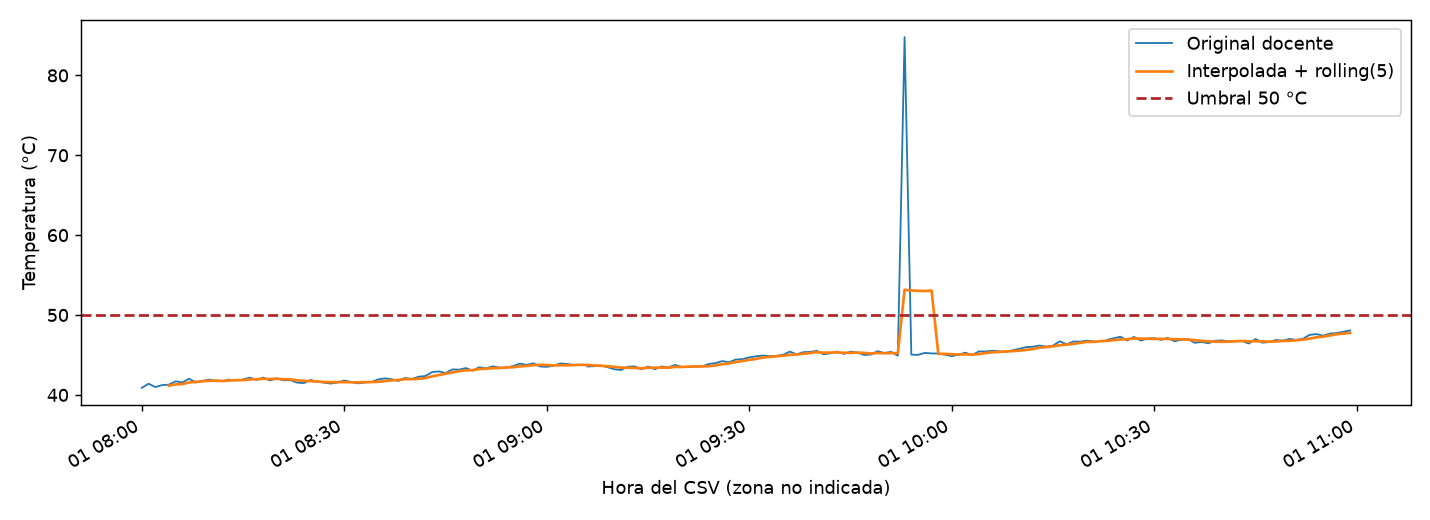

In [3]:
if __name__ == "__main__":
    report = run()
    print(json.dumps(report, ensure_ascii=False, indent=2))
    if "__file__" not in globals():
        from IPython.display import Image, display

        display(
            Image(filename=str(HERE / "resultados" / "docente" / "tenperatura.png"))
        )